In [15]:
import numpy as np
def quadratic_form(A, b, c, x):
    return x.T @ A @ x + b.T @ x + c

def derivative_qf(A, b, x):
    return A @ x + b

In [21]:
def gradient_descend(f, df, x0, alpha, n_iter, tol):
    # let f be a quadratic function of x Rn
    xs = [x0]
    fs = [f(x0)]

    x = np.array(x0)
    for _ in range(n_iter):
        grad = df(x)
        x = x - alpha * grad

        xs.append(x.copy()); fs.append(f(x))
        if np.linalg.norm(x-xs[-2]) < tol:
            break
    
    return np.array(xs), np.array(fs)

In [22]:
def gradient_descend_quadratic(A, b, c, x0, alpha, n_iter, tol):
    f = lambda x: quadratic_form(A, b, c, x)
    df = lambda x: derivative_qf(A, b, x)
    return gradient_descend( f, df, x0, alpha, n_iter, tol)

In [128]:
A = np.array([[1, -1],[-1, 3]])
b = np.array([3,2])
c = -1
x0 = np.array([-4, 0])
f = lambda x: quadratic_form(A, b, c, x)

xs, fs = gradient_descend_quadratic(A, b, c, x0, alpha=0.1, n_iter=10000, tol=0.0001)

In [27]:
xs

array([[-2.00000000e+00,  0.00000000e+00],
       [-1.60000000e+00,  2.00000000e-01],
       [-1.30000000e+00,  3.00000000e-01],
       [-1.07000000e+00,  3.40000000e-01],
       [-8.90000000e-01,  3.45000000e-01],
       [-7.46500000e-01,  3.30500000e-01],
       [-6.30250000e-01,  3.06000000e-01],
       [-5.34800000e-01,  2.77225000e-01],
       [-4.55562500e-01,  2.47537500e-01],
       [-3.89203750e-01,  2.18832500e-01],
       [-3.33246250e-01,  1.92103125e-01],
       [-2.85807312e-01,  1.67796813e-01],
       [-2.45425531e-01,  1.46038500e-01],
       [-2.10944275e-01,  1.26769503e-01],
       [-1.81432370e-01,  1.09833080e-01],
       [-1.56129204e-01,  9.50263928e-02],
       [-1.34406003e-01,  8.21313954e-02],
       [-1.15737942e-01,  7.09325770e-02],
       [-9.96836110e-02,  6.12265981e-02],
       [-8.58695486e-02,  5.28269798e-02],
       [-7.39783369e-02,  4.55658407e-02],
       [-6.37392536e-02,  3.92939222e-02],
       [-5.49207951e-02,  3.38796709e-02],
       [-4.

In [28]:
import matplotlib.pyplot as plt

In [64]:
def create_grid(lim_x, lim_y, f,n=50):
    X0, X1 = np.meshgrid(np.linspace(lim_x[0],lim_x[1], n), np.linspace(lim_y[0], lim_y[1], n))
    Z = np.zeros_like(X0)
    for i in range(X0.shape[0]):
        for j in range(X0.shape[1]):
            Z[i,j] = f(np.array([X0[i,j], X1[i,j]]))
    return X0, X1, Z

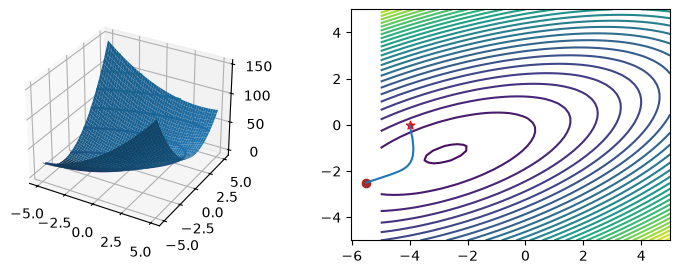

In [133]:
fig = plt.figure(figsize=(14,3))
ax1 = fig.add_subplot(1,3,1, projection='3d')
ax2 = fig.add_subplot(1,3,2)

X0, X1, Z = create_grid([-5, 5], [-5,5], f)

ax1.plot_surface(X0, X1, Z, antialiased=True)
ax1.contour(X0, X1, Z)
ax2.contour(X0, X1, Z, levels=30)
ax2.plot(xs[:,0], xs[:,1])
ax2.scatter(x0[0], x0[1], marker='*', color='red')
ax2.scatter(xs[-1, 0], xs[-1,1], marker='o', color='brown')

In [120]:
test_alpha = lambda a: gradient_descend_quadratic(A, b, c, x0, alpha=a, n_iter=100, tol=0.0001) 
def compare_alpha(alphas):
    # usar con 3 alphas 
    n = len(alphas); print(n)
    cs = ['green', 'purple', 'orange']; ms = ['x', 'o', '*']
    fig = plt.figure(figsize=(17,4))
    _ax = fig.add_subplot(1,n+1, n+1)
    for i,a in enumerate(alphas):
        xs, fs = test_alpha(a)
        print(xs.shape, fs.shape)
        _ax.plot(np.arange(fs.shape[-1]),fs,color=cs[i], label=f'alpha={a}'); _ax.legend()
        
        X0, X1, Z = create_grid([-5,5], [-5, 5], f)
        ax = fig.add_subplot(1,n+1,i+1)
        ax.contour(X0, X1, Z, levels=30)
        
        ax.plot(xs[:,0], xs[:,1], color='red')
        ax.scatter(xs[0,0], xs[0,1], color='black', marker='*')
        ax.scatter(xs[-1,0], xs[-1, 1], color='black', marker='o')

3
(101, 2) (101,)
(101, 2) (101,)
(101, 2) (101,)


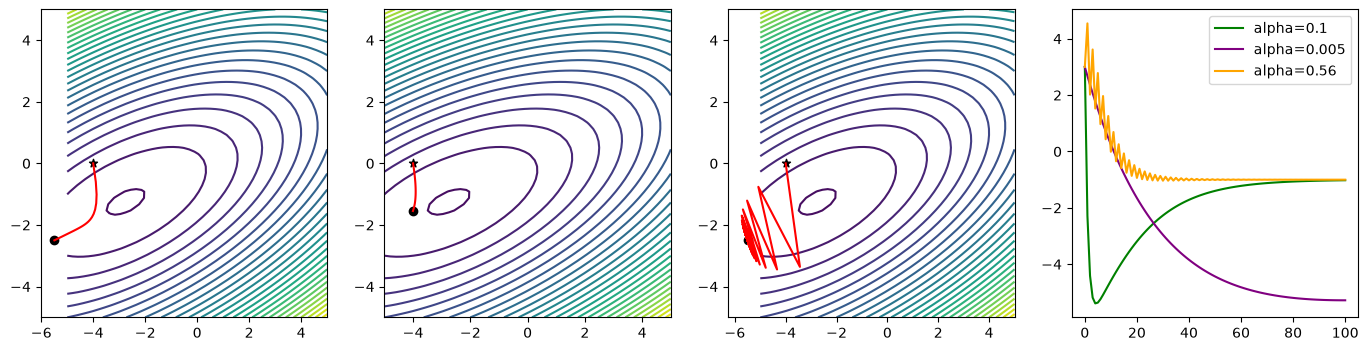

In [130]:
compare_alpha([0.1, 0.005, 0.56])